# Air Quality Monitoring at NEIU's Main Campus

Data collected by a [QuantAQ MODULAIR™](https://www.quant-aq.com/products/modulair) 
sensor mounted on the roof of the BBH building at Northeastern Illinois University's 
main campus in Chicago. The MODULAIR measures four gas-phase pollutants — ozone (O₃), 
nitrogen monoxide (NO), nitrogen dioxide (NO₂), and carbon monoxide (CO) — alongside 
particulate matter at three size fractions (PM₁, PM₂₅, and PM₁₀) at one-minute 
intervals. Data are retrieved from the QuantAQ cloud platform and plotted here in UTC.

In [ ]:
# Standard library
import datetime as dt
import calendar
import ssl

# Third party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from suntime import Sun

## Import Data

In [ ]:
# To aoid SSL certificate error

ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
# read QuantAQ MODULAIR data (one minute intervals)


aqdata = pd.read_csv("https://physics.neiu.edu/~anderson/research/data/quantaq/MOD-06-2023.csv",index_col=0,parse_dates=False)
#aqdata = pd.read_csv("data/MOD-06-2023.csv",index_col=0,parse_dates=False)
sensor = "QuantAQ MODULAIR\u2122"  # A string to indentify the sensor


## Data Wrangling

In [11]:
# convert timezone naive to timezone aware datetimes

aqdata['timestamp_local'] = pd.to_datetime(aqdata['timestamp_local'],utc=False)
aqdata.index = pd.to_datetime(aqdata.index,utc=True)

# setup start time, time intervals, and end times

Ndays = 7
solar_day = dt.timedelta(days=1)

start_dt = dt.datetime(2023,6,21,tzinfo=dt.timezone.utc)
end_dt = start_dt + Ndays*solar_day
print("year=",start_dt.year)

# subset the data frame to include a restricted time interval
# so max values is selected for the plotted range
 
mask = (aqdata.index > start_dt) & (aqdata.index <= end_dt)
aqd = aqdata.loc[mask]

max_o3 = aqd['o3'].max()
max_co = aqd['co'].max()
max_pm1 = aqd['pm1'].max()
max_pm25 = aqd['pm25'].max()
max_pm10 = aqd['pm10'].max()
max_pm = max(max_pm1,max_pm25,max_pm10)

print('max o3 = ',max_o3)
max_ppb = max_o3


year= 2023
max o3 =  71.958


In [12]:
# Nighttime shading

latitude  =  41.9803
longitude = -87.717 

sun=Sun(latitude,longitude)

dayname = [None]*(Ndays+1)

# Day of the week, e.g. Monday
dayname[0] = calendar.day_name[start_dt.weekday()]
print('dayname=',dayname)

sunrise = [None] * (Ndays + 1)
sunset  = [None] * (Ndays + 1)

for i in range(Ndays + 1):
    day        = start_dt + i * solar_day
    sunrise[i] = sun.get_sunrise_time(day).astimezone(dt.timezone.utc)
    sunset[i]  = sun.get_sunset_time(day + solar_day).astimezone(dt.timezone.utc)
    print(f"Day {i}: sunrise {sunrise[i].strftime('%Y-%m-%d %H:%M')}  "
          f"sunset {sunset[i].strftime('%Y-%m-%d %H:%M')}")

dayname= ['Wednesday', None, None, None, None, None, None, None]
Day 0: sunrise 2023-06-21 10:15  sunset 2023-06-22 01:30
Day 1: sunrise 2023-06-22 10:15  sunset 2023-06-23 01:30
Day 2: sunrise 2023-06-23 10:16  sunset 2023-06-24 01:30
Day 3: sunrise 2023-06-24 10:16  sunset 2023-06-25 01:30
Day 4: sunrise 2023-06-25 10:16  sunset 2023-06-26 01:30
Day 5: sunrise 2023-06-26 10:16  sunset 2023-06-27 01:30
Day 6: sunrise 2023-06-27 10:17  sunset 2023-06-28 01:30
Day 7: sunrise 2023-06-28 10:18  sunset 2023-06-29 01:30


## Timeseries Visualization

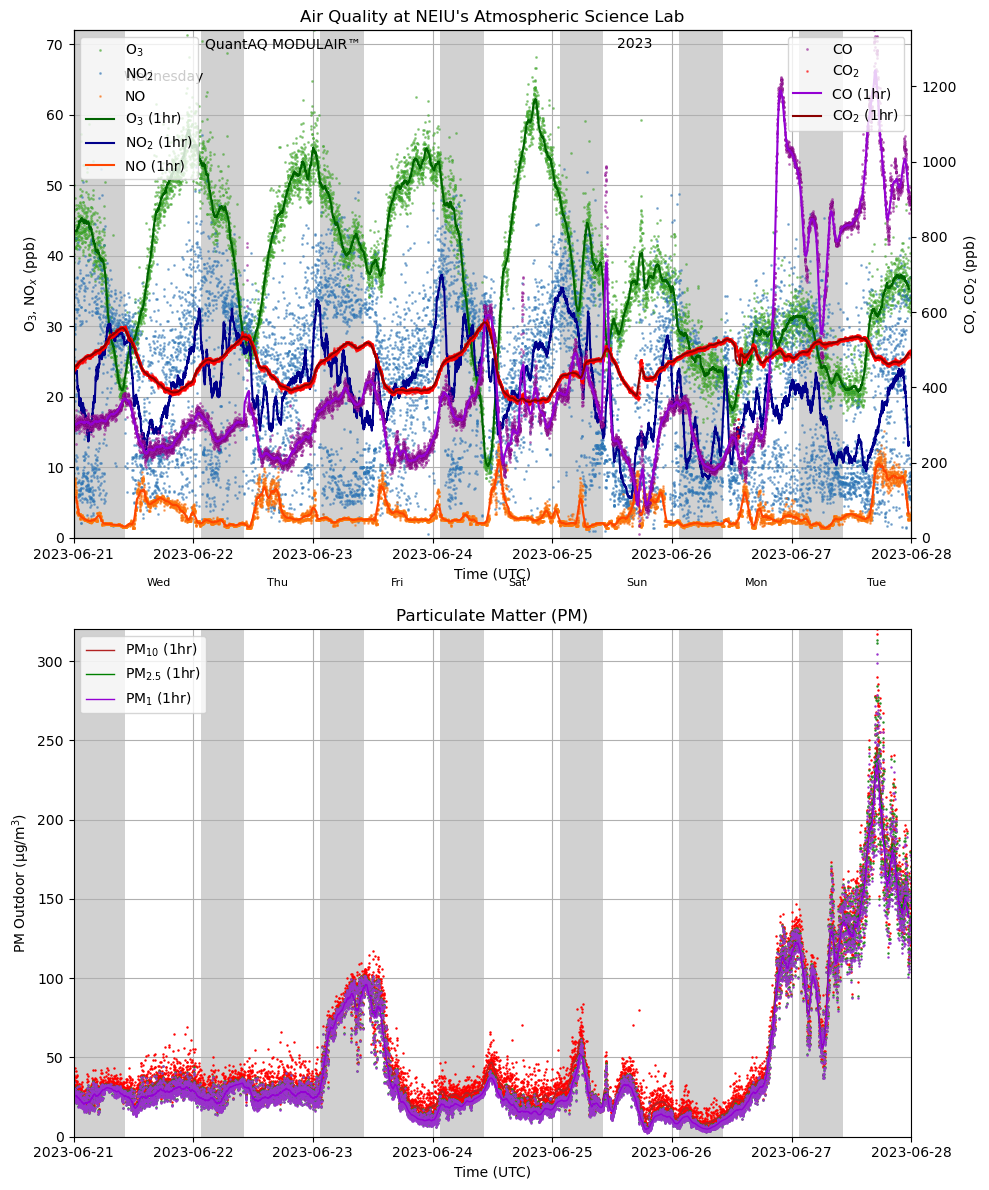

In [15]:
import matplotlib.transforms as transforms

fig = plt.figure(figsize=(10,12))
ax1a = fig.add_subplot(2, # nrows
                       1, # ncols
                       1) # postition

ax2a = fig.add_subplot(2, # nrows
                       1, # ncols
                       2) # postition
ax1a.axis([start_dt,end_dt,0,max_ppb])

# Night before first sunrise
ax1a.add_patch(Rectangle(
    (start_dt, 0), sunrise[0] - start_dt, max_ppb,
    facecolor="dimgray", alpha=0.3
))

for i in range(Ndays):
    ax1a.add_patch(Rectangle(
        (sunset[i], 0), sunrise[i+1] - sunset[i], max_ppb,
        facecolor="dimgray", alpha=0.3
    ))
    
ax1a.set_title('Air Quality at NEIU\'s Atmospheric Science Lab')
ax1a.set_xlabel('Time (UTC)')
ax1a.set_ylabel('O${}_3$, NO${}_x$ (ppb)')
ax1a.grid(True)
ax1a.annotate(dayname[0], 
               xy=(start_dt+0.75*solar_day,0.90*max_ppb),
                horizontalalignment='center')
ax1a.annotate(sensor, 
               xy=(start_dt+0.25*(end_dt-start_dt),max_o3-1),
               verticalalignment='top',
               horizontalalignment='center',
               fontsize=10)
ax1a.annotate(start_dt.year, 
               xy=(start_dt+0.67*(end_dt-start_dt),max_o3-1),
               verticalalignment='top',
               horizontalalignment='center',
               fontsize=10)
ax1a.plot(aqd.index,
           aqd['o3'],
           label='O${}_3$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:olive', # marker face color
           color='tab:green',
           alpha=0.5)
ax1a.plot(aqd.index,
           aqd['no2'],
           label='NO${}_2$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:purple',
           alpha=0.5)
ax1a.plot(aqd.index,
           aqd['no'],
           label='NO',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='tab:red',
           alpha=0.5)

ax1b = ax1a.twinx()
ax1b.set_ylabel('CO, CO${}_2$ (ppb)')
ax1b.axis([start_dt,end_dt,0,max_co])
ax1b.plot(aqd.index,
           aqd['co'],
           label='CO',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='violet', # marker face color
           color='purple',
           alpha=0.5)
ax1b.plot(aqd.index,
           aqd['co2'],
           label='CO${}_2$',
           linestyle='none',
           marker='o',
           markersize=1,
           mfc='red', # marker face color
           color='red',
           alpha=0.5)
ax1a.plot(aqd.index, aqd['o3'].rolling(60,center=True).mean(),
           label="O${}_3$ (1hr)",color='darkgreen')
ax1a.plot(aqd.index, aqd['no2'].rolling(60,center=True).mean(),
           label="NO${}_2$ (1hr)",color='darkblue')
ax1a.plot(aqd.index, aqd['no'].rolling(60,center=True).mean(),
           label="NO (1hr)",color='orangered')
ax1b.plot(aqd.index, aqd['co'].rolling(60,center=True).mean(),
           label="CO (1hr)",color='darkviolet')
ax1b.plot(aqd.index, aqd['co2'].rolling(60,center=True).mean(),
           label="CO${}_2$ (1hr)",color='darkred')
ax1a.legend(loc='upper left')
ax1b.legend(loc='upper right')
# PM
ax2a.axis([start_dt,end_dt,0,max_pm])
ax2a.grid(True)

ax2a.add_patch(Rectangle(
    (start_dt, 0), sunrise[0] - start_dt, max_pm,
    facecolor="dimgray", alpha=0.3
))
for i in range(Ndays):
    ax2a.add_patch(Rectangle(
        (sunset[i], 0), sunrise[i+1] - sunset[i], max_pm,
        facecolor="dimgray", alpha=0.3
    ))

ax2a.plot(aqd.index,
           aqd['pm10'],
#          label='PM${}_{10}$',
           linestyle='none',
           marker='o',
           markersize=0.75,
           mfc='orangered', # marker face color
           color='red',
#           alpha=0.5
           )
ax2a.plot(aqd.index, 
          aqd['pm10'].rolling(60,center=True).mean(),
          label="PM${}_{10}$ (1hr)",color='firebrick',linewidth=1)

ax2a.plot(aqd.index,
          aqd['pm25'], #         label='PM${}_2.5}$',
          linestyle='none',
          marker='o',
          markersize=0.75,
          mfc='limegreen', # marker face color
          color='forestgreen', #  alpha=0.5
          )

ax2a.plot(aqd.index, 
          aqd['pm25'].rolling(60,center=True).mean(),
          label="PM${}_{2.5}$ (1hr)",color='green',
          linewidth=1)

ax2a.plot(aqd.index,
           aqd['pm1'],
#           label='PM1',
           linestyle='none',
           marker='o',
           markersize=0.75,
           mfc='mediumorchid', # marker face color
           color='darkorchid',
#           alpha=0.5
           )
ax2a.plot(aqd.index,
          aqd['pm1'].rolling(60,center=True).mean(),
           label="PM${}_{1}$ (1hr)",color='darkviolet', linewidth=1)

ax2a.set_title('Particulate Matter (PM)')
ax2a.set_xlabel('Time (UTC)')
ax2a.set_ylabel('PM Outdoor (µg/m${}^3$)')
ax2a.legend(loc='upper left')

fig.tight_layout(h_pad=2)
#fig.autofmt_xdate()

import matplotlib.transforms as transforms

blended = transforms.blended_transform_factory(ax1a.transData, ax1a.transAxes)

for i in range(Ndays + 1):
    noon_utc = start_dt + i * solar_day + dt.timedelta(hours=17)
    if start_dt <= noon_utc <= end_dt:
        ax1a.annotate(
            calendar.day_abbr[(start_dt + i * solar_day).weekday()],
            xy=(noon_utc, -0.08),
            xycoords=blended,
            ha='center', va='top',
            fontsize=8,
        )

plt.show()
           


In [ ]:
fig.savefig("figures/QAQ_time_series.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/QAQ_time_series.pdf", bbox_inches="tight")
print("Saved QuantAQ figures")